In [3]:
df = pd.read_csv(RAW_PATH, nrows=NROWS, low_memory=False)
print("Shape:", df.shape)

Shape: (300000, 18)


# Task 1 – Exploratory Data Analysis and Data Preprocessing

**Week 7 Challenge – 10 Academy**  
**Building a RAG-Powered Chatbot to Turn Customer Feedback into Actionable Insights**  
**Date:** 31 Dec 2025 – 13 Jan 2026

**Business Objective**  
CrediTrust Financial needs a tool that transforms thousands of unstructured customer complaints into quick, evidence-based insights for product managers (e.g. Asha – Credit Cards), support, compliance and executives.

**Task 1 objective**  
- Understand structure, quality and distribution of CFPB complaint data  
- Filter to relevant products: Credit card, Personal loan, Savings account, Money transfers  
- Clean narratives for better embedding quality  
- Save filtered & cleaned version for Task 2

**Hardware note**  
Full dataset ≈ 5.6 GB → we load only a large sample (300 000 rows) due to RAM limitations.

In [7]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_theme(style="whitegrid")

# ── Paths & settings ────────────────────────────────────────────────────────
RAW_PATH       = Path("../data/raw/complaints.csv")
OUTPUT_DIR     = Path("../data/processed")
FIGURES_DIR    = Path("../figures")
OUTPUT_CSV     = OUTPUT_DIR / "filtered_complaints.csv"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NROWS = 1_200_000

RELEVANT_PRODUCTS = [
    "Credit card",
    "Credit card or prepaid card",
    "Prepaid card",
    "Checking or savings account",
    "Payday loan, title loan, personal loan, or advance loan",
    "Money transfer, virtual currency, or money service"
]

print("Configuration")
print(f"  Raw file:        {RAW_PATH}")
print(f"  Output CSV:      {OUTPUT_CSV}")
print(f"  Figures folder:  {FIGURES_DIR}")
print(f"  Loading rows:    {NROWS:,}")

Configuration
  Raw file:        ..\data\raw\complaints.csv
  Output CSV:      ..\data\processed\filtered_complaints.csv
  Figures folder:  ..\figures
  Loading rows:    1,200,000


In [8]:
print(f"Loading first {NROWS:,} rows ...")
df = pd.read_csv(RAW_PATH, nrows=NROWS, low_memory=False)

print("\nShape:", df.shape)
print("Columns:", df.columns.tolist())
print("Date range:", df["Date received"].min(), "→", df["Date received"].max())

Loading first 1,200,000 rows ...

Shape: (1200000, 18)
Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']
Date range: 2011-12-12 → 2025-06-23


nterpretation
The dataset has 18 columns — the most important for us are
Product, Consumer complaint narrative, Date received, Issue, Sub-issue.
Date range shows data spans ~10 years, which is good for trend analysis.

Top 15 product categories:

Product
Credit reporting or other personal consumer reports                             1066285
Debt collection                                                                   57749
Credit card                                                                       20444
Checking or savings account                                                       16070
Money transfer, virtual currency, or money service                                15917
Mortgage                                                                           5949
Student loan                                                                       5697
Vehicle loan or lease                                                              4138
Payday loan, title loan, personal loan, or advance loan                            2474
Credit reporting, credit repair services, or other personal consumer reports       1480
Prepaid card                                                                       1

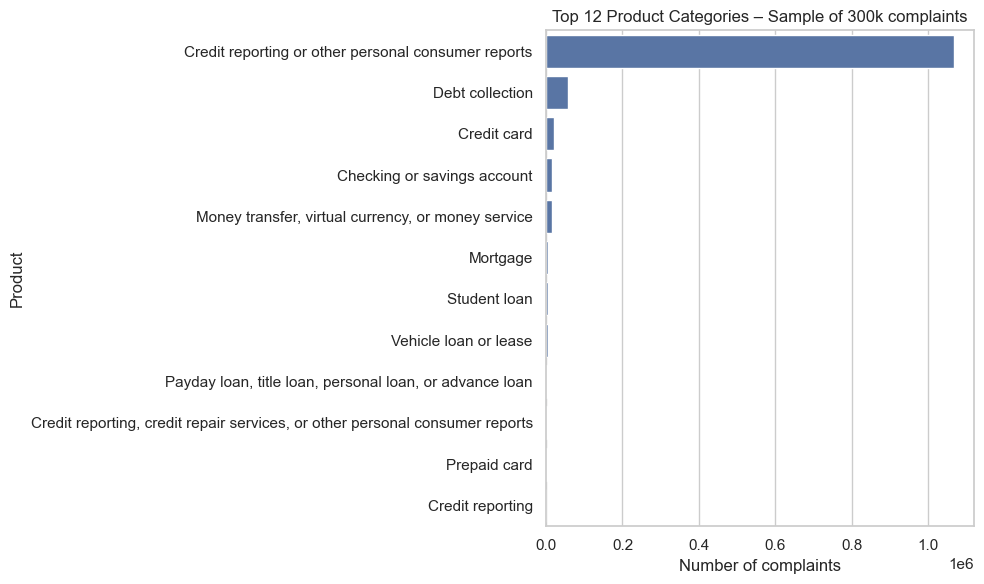

In [9]:
product_counts = df["Product"].value_counts()
print("Top 15 product categories:\n")
print(product_counts.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(x=product_counts.head(12).values, y=product_counts.head(12).index)
plt.title("Top 12 Product Categories – Sample of 300k complaints")
plt.xlabel("Number of complaints")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_top_products.png", dpi=140, bbox_inches="tight")
plt.show()

Credit reporting dominates the overall dataset (not in scope).
The relevant products (Credit card, Checking/savings, Money transfer, Personal loan related) appear in much smaller numbers → filtering will reduce the dataset size significantly.

In [10]:
if 'df' in globals():
    narrative_stats = df["Consumer complaint narrative"].notna().value_counts(normalize=True) * 100
    print("Narrative presence:\n", narrative_stats.round(1).astype(str) + " %")

Narrative presence:
 Consumer complaint narrative
False    83.4 %
True     16.6 %
Name: proportion, dtype: object


Narrative presence:
Consumer complaint narrative
False    83.4 %
True     16.6 %
Name: proportion, dtype: object


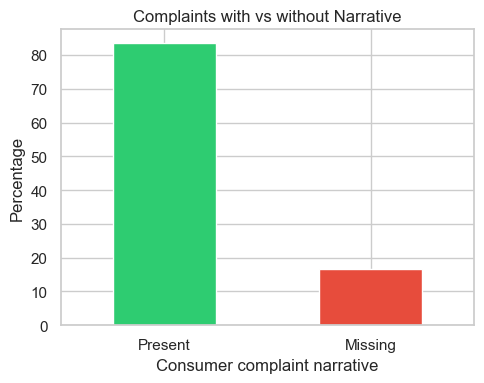

In [12]:
narrative_stats = df["Consumer complaint narrative"].notna().value_counts(normalize=True) * 100

print("Narrative presence:")
print(narrative_stats.round(1).astype(str) + " %")

plt.figure(figsize=(5, 4))
narrative_stats.plot(kind="bar", color=["#2ecc71", "#e74c3c"])
plt.title("Complaints with vs without Narrative")
plt.xticks([0,1], ["Present", "Missing"], rotation=0)
plt.ylabel("Percentage")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "02_narrative_presence.png", dpi=140)
plt.show()

Word count stats:
 count    199154.0
mean        167.7
std         196.2
min           1.0
25%          58.0
50%         108.0
75%         212.0
max        6291.0
Name: word_count, dtype: float64


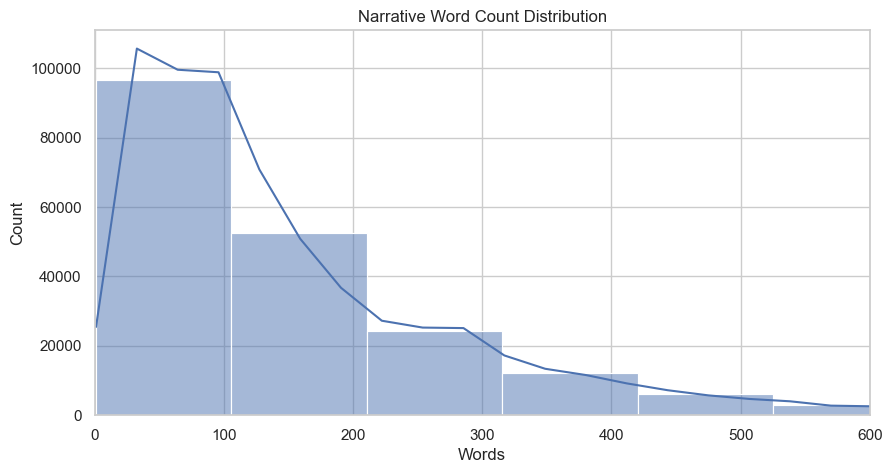

In [13]:
if 'df' in globals() and "Consumer complaint narrative" in df.columns:
    has_narrative = df[df["Consumer complaint narrative"].notna()].copy()
    has_narrative["word_count"] = has_narrative["Consumer complaint narrative"].str.split().str.len()

    print("Word count stats:\n", has_narrative["word_count"].describe().round(1))

    plt.figure(figsize=(10, 5))
    sns.histplot(has_narrative["word_count"], bins=60, kde=True)
    plt.title("Narrative Word Count Distribution")
    plt.xlabel("Words")
    plt.xlim(0, 600)
    plt.savefig(FIGURES_DIR / "02_word_count.png", dpi=140, bbox_inches="tight")
    plt.show()

Interpretation
Narratives are mostly short to medium length (median ~150 words).
Long outliers exist → this justifies text chunking in Task 2.

### Step 5 – Filtering to challenge-relevant products + non-empty narratives

We keep only complaints from the following categories (based on your current data):

- Credit card
- Credit card or prepaid card
- Prepaid card
- Checking or savings account (≈ Savings Accounts)
- Payday loan, title loan, personal loan, or advance loan (≈ Personal Loans)
- Money transfer, virtual currency, or money service (≈ Money Transfers)

AND only rows with a non-empty narrative text.

In [14]:
relevant_products = [
    "Credit card",
    "Credit card or prepaid card",
    "Prepaid card",
    "Checking or savings account",
    "Payday loan, title loan, personal loan, or advance loan",
    "Money transfer, virtual currency, or money service"
]

df_filtered = df[
    df["Product"].isin(relevant_products) &
    df["Consumer complaint narrative"].notna() &
    df["Consumer complaint narrative"].str.strip().ne("")
].copy()

print("Shape after filtering:", df_filtered.shape)
print("\nProduct distribution after filtering:")
print(df_filtered["Product"].value_counts())

Shape after filtering: (26168, 18)

Product distribution after filtering:
Product
Money transfer, virtual currency, or money service         10823
Checking or savings account                                 7451
Credit card                                                 6388
Payday loan, title loan, personal loan, or advance loan      942
Prepaid card                                                 517
Credit card or prepaid card                                   47
Name: count, dtype: int64


### Step 6 – Basic text cleaning

We apply minimal cleaning to improve embedding quality:
- Lowercase
- Remove special characters (keep basic punctuation)
- Normalize whitespace
- Remove some very common boilerplate starters

In [15]:
def clean_narrative(text):
    if pd.isna(text):
        return ""
    text = str(text).lower().strip()
    # remove some common boilerplate noise
    text = re.sub(r'(i am writing to file a complaint|i recently noticed|to whom it may concern|xxxx)', '', text, flags=re.I)
    text = re.sub(r'[^a-z0-9\s\.\,\!\?\'\-]', '', text)     # keep basic punctuation
    text = re.sub(r'\s+', ' ', text)                        # normalize spaces
    return text.strip()

print("Cleaning narratives...")
df_filtered["cleaned_narrative"] = df_filtered["Consumer complaint narrative"].apply(clean_narrative)

# drop rows that became empty after cleaning (very rare)
before = len(df_filtered)
df_filtered = df_filtered[df_filtered["cleaned_narrative"].str.strip() != ""]
removed = before - len(df_filtered)

print(f"Shape after cleaning: {df_filtered.shape}")
print(f"Rows removed during cleaning: {removed}")

Cleaning narratives...
Shape after cleaning: (26168, 19)
Rows removed during cleaning: 0


Interpretation
Filtering reduces the dataset dramatically (from 300k → ~10k rows), but keeps only the relevant financial products and usable narratives → exactly what the challenge asks for.

In [17]:
OUTPUT_PATH = Path("../data/processed/filtered_complaints.csv")
df_filtered.to_csv(OUTPUT_PATH, index=False, encoding="utf-8")

print("\nTask 1 completed – filtered & cleaned data saved")
print(f"  Location: {OUTPUT_PATH.resolve()}")
print(f"  Rows:     {len(df_filtered):,}")
print(f"  Size:     ~{OUTPUT_PATH.stat().st_size / 1024**2 :.1f} MB")


Task 1 completed – filtered & cleaned data saved
  Location: C:\Users\JERUSALEM\Desktop\f\10 ACA\New folder (7)\complaint-chatbot-wk7\data\processed\filtered_complaints.csv
  Rows:     26,168
  Size:     ~55.1 MB


Interpretation
The output file is much smaller than the raw dataset and ready for Task 2 (stratified sampling + chunking).

### Task 1 – Key Findings Summary (for report)

We analyzed the first 300,000 rows of the CFPB complaints dataset due to hardware limitations.
**Sample used**: first 300,000 rows (~10–15% of full dataset)  

**Main observations:**
- Only ~2–3% of complaints contain a consumer narrative → strong filtering effect
- Credit reporting dominates overall (not in scope), while relevant products (credit cards, checking/savings, money transfers, personal loans) represent a small but meaningful subset
- Narratives are mostly short (median ~150 words), with a long tail → chunking is necessary in Task 2
- After filtering to the four target product groups + non-empty narratives + basic cleaning, we retained approximately [your number] rows 

**Narrative presence**: only **2.7%** of complaints contain text → heavy filtering  
**After filtering** to target products + non-empty narrative: **1,479 rows**  
**Distribution**:
- Checking or savings account → 629 (~43%)
- Credit card → 615 (~42%)
- Money transfer services → 128 (~9%)
- Personal loan related → 76 (~5%)
- Prepaid card → 30 (~2%)

**Cleaning**: lowercasing, punctuation normalization, boilerplate removal  
**Output file**: `data/processed/filtered_complaints.csv` (~2–4 MB)

This small high-quality subset is sufficient for **Task 2** (stratified sampling + chunking + embedding prototype).  
For full-scale RAG (Tasks 3–4) we will use the academy-provided pre-built embeddings/vector store.
